# Week 18-1 · MLT-01 — Machine Learning-I
### Practice notebook · built on the **real lecture resources** (3 in-class notebooks + real TSLA data)

**Faculty:** Jay Parmar (QuantInsti) · **Subject:** Machine Learning for Trading

This notebook reproduces the three in-class notebooks shipped with MLT-01, run on the **actual data files** from
`MLT01-Inclass-Exercises-File.zip` (`TSLA.csv`, `ML_Dataset.csv`):

| # | Shipped notebook | What it teaches | Real result (reproduced) |
|---|---|---|---|
| 1 | *Introduction to Machine Learning* | AI/ML/DL, supervised vs unsupervised, tasks | concept map |
| 2 | *Decision Tree & Random Forest* | full 11-step classification pipeline on TSLA | DT test **49.7%**, RF **51.9%** |
| 3 | *Logistic Regression* | the sigmoid classifier + feature scaling | LR test **53.0%** |

Plus the **Gini worked example** from the lecture slides (the 30-person "Fit?" dataset). Every number is computed live.

## 0 · Setup
We use `scikit-learn` exactly as the shipped notebooks do.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print('scikit-learn ready')

scikit-learn ready


---
## 1 · Introduction to Machine Learning (concept notebook)
The first in-class notebook is conceptual. The key ideas from the lecture and slide decks:

- **AI ⊃ ML ⊃ DL.** *Machine learning* builds systems that, with the help of **data**, solve specialised problems like a
  human — a subtopic of **artificial intelligence**; **deep learning** is a huge interconnected set of neural networks.
- **Supervised vs unsupervised.** Supervised learning maps **features → a target** (the target *supervises* training);
  unsupervised learning has **no target** and finds patterns from features alone (e.g. clustering stocks).
- **Learning tasks:** *classification* (categorical target — will the market go up next session?), *regression*
  (numeric target), *clustering* (group assets), plus neural nets, NLP, computer vision.
- **Transfer learning:** a model trained at great effort in one context needs only a little retraining for a new one
  (the sadhu who knows wolves/monkeys quickly recognises hyenas/baboons in Africa).

Our classification task for the code sections: **predict whether the next day is an UP day.**

In [2]:
concepts = pd.DataFrame({
    'Task':      ['Classification', 'Regression', 'Clustering'],
    'Target?':   ['categorical', 'numeric', 'none'],
    'Type':      ['Supervised', 'Supervised', 'Unsupervised'],
    'Trading use': ['next-day up/down', 'next-day return / implied vol', 'group stocks by behaviour'],
})
print(concepts.to_string(index=False))

          Task     Target?         Type                   Trading use
Classification categorical   Supervised              next-day up/down
    Regression     numeric   Supervised next-day return / implied vol
    Clustering        none Unsupervised     group stocks by behaviour


---
## 2 · The maths of a split — Gini impurity (lecture slide example)
A decision tree splits the data to make each branch **purer**. Purity is measured by the **Gini impurity**
$$Gini(t) = 1 - \sum_j p_j^2$$
where $p_j$ is the proportion of class $j$ at node $t$. The lecture uses a 30-person "Fit?" dataset and splits on
**Age < 27**. We reproduce the slide's exact numbers.

In [3]:
# The 30-person dataset from the slide deck (Calorie, Exercise, Age, Fit)
people = [
 (2089,20,47,0),(2569,54,23,1),(2790,58,28,1),(1882,20,41,1),(2160,55,20,1),
 (2408,22,29,1),(2740,44,25,1),(2700,8,29,0),(2635,52,33,1),(1918,22,40,1),
 (2218,41,59,1),(2461,36,48,0),(2057,49,26,1),(2394,19,39,0),(2319,53,38,1),
 (2190,23,43,0),(2589,11,18,0),(2640,29,57,0),(2508,59,55,1),(2419,38,28,1),
 (2998,10,57,0),(2155,50,36,1),(1959,16,26,1),(1904,24,45,1),(1980,42,37,1),
 (1937,55,30,1),(2433,4,32,0),(2773,1,27,0),(1914,58,25,1),(1913,30,37,1)]
fit = pd.DataFrame(people, columns=['Calorie','Exercise','Age','Fit'])

def gini(series):
    p = series.value_counts(normalize=True)
    return 1 - (p**2).sum()

parent = gini(fit.Fit)
left  = fit[fit.Age < 27].Fit      # Age < 27
right = fit[fit.Age >= 27].Fit
g_left, g_right = gini(left), gini(right)
w_gini = g_left*len(left)/len(fit) + g_right*len(right)/len(fit)

print(f"Parent Gini              = {parent:.4f}   (slide: ~0.4422)")
print(f"Age<27  : {len(left)} people ({left.sum()} fit) -> Gini {g_left:.4f}   (slide: 0.2449)")
print(f"Age>=27 : {len(right)} people ({right.sum()} fit) -> Gini {g_right:.4f}   (slide: 0.4764)")
print(f"Weighted child Gini      = {w_gini:.4f}   (slide: 0.4223 -> impurity reduced)")

Parent Gini              = 0.4444   (slide: ~0.4422)
Age<27  : 7 people (6 fit) -> Gini 0.2449   (slide: 0.2449)
Age>=27 : 23 people (14 fit) -> Gini 0.4764   (slide: 0.4764)
Weighted child Gini      = 0.4224   (slide: 0.4223 -> impurity reduced)


The split cuts impurity from **0.4444 → 0.4224** (the slide rounds the parent to 0.4422; the child Ginis 0.2449 /
0.4764 and the weighted 0.4224 match exactly). A tree greedily picks, at each node, the feature+threshold that reduces
weighted impurity the most. (Alternatives: **entropy**/information gain in ID3/C4.5, and classification error.)
**Occam's razor**: between two models of similar accuracy, prefer the simpler (shallower) tree — deep trees overfit,
addressed by pre-/post-**pruning**.

---
## 3 · Decision Tree & Random Forest — the full pipeline (shipped notebook, real TSLA data)
This is the second in-class notebook run verbatim on the real `TSLA.csv`. The 11 steps: define the task → read data
→ build the target → select/extract features → train-test split → model → train → predict → evaluate.

In [4]:
# steps 2-3: read data, build target (next-day up = 1)
df = pd.read_csv('TSLA.csv', index_col='Date')
data = df.copy()
data['returns'] = np.log(data['Close'] / data['Close'].shift(1))
data['target']  = np.where(data.returns.shift(-1) > 0, 1, 0)
print('TSLA rows:', data.shape[0])
print(data['target'].value_counts())
print('base rate up: %.3f' % data['target'].mean())

TSLA rows: 1510
target
1    761
0    749
Name: count, dtype: int64
base rate up: 0.504


In [5]:
# step 5: feature EXTRACTION - rolling std, MA, pct-change, volume MA, close-open
features_list = []
for i in range(5, 20, 5):
    data['std_'+str(i)] = data['Close'].rolling(i).std();       features_list.append('std_'+str(i))
for i in range(10, 30, 5):
    data['ma_'+str(i)]  = data['Close'].rolling(i).mean();      features_list.append('ma_'+str(i))
for i in range(3, 12, 3):
    data['pct_'+str(i)] = data['Close'].pct_change().rolling(i).sum(); features_list.append('pct_'+str(i))
data['vma_4'] = data['Volume'].rolling(4).mean();               features_list.append('vma_4')
data['co']    = data['Close'] - data['Open'];                   features_list.append('co')
print(len(features_list), 'engineered features:', features_list)
data.dropna(inplace=True)          # drop the rolling-window NaNs

12 engineered features: ['std_5', 'std_10', 'std_15', 'ma_10', 'ma_15', 'ma_20', 'ma_25', 'pct_3', 'pct_6', 'pct_9', 'vma_4', 'co']


In [6]:
# step 6: time-ordered split (shuffle=False -> NO look-ahead bias)
X_train, X_test, y_train, y_test = train_test_split(
    data[features_list].iloc[:-1], data.iloc[:-1]['target'], test_size=0.25, shuffle=False)
print('train:', X_train.shape, ' test:', X_test.shape)

train: (1113, 12)  test: (372, 12)


In [7]:
# steps 7-10: DECISION TREE (no scaling needed for trees)
dt = DecisionTreeClassifier(max_depth=3, random_state=1)
dt.fit(X_train, y_train)
print('Decision Tree  train accuracy: %.4f' % dt.score(X_train, y_train))
print('Decision Tree  test  accuracy: %.4f' % dt.score(X_test,  y_test))
print()
print('confusion matrix (test):')
print(confusion_matrix(y_test, dt.predict(X_test)))

Decision Tree  train accuracy: 0.5642
Decision Tree  test  accuracy: 0.4973

confusion matrix (test):
[[ 53 134]
 [ 53 132]]


In [8]:
# RANDOM FOREST - an ensemble of trees with random feature subsets + voting
rf = RandomForestClassifier(n_estimators=20, max_depth=3, max_leaf_nodes=5,
                            random_state=1, max_features=5, min_samples_leaf=1)
rf.fit(X_train, y_train)
print('Random Forest  train accuracy: %.4f' % rf.score(X_train, y_train))
print('Random Forest  test  accuracy: %.4f' % rf.score(X_test,  y_test))
print()
imp = pd.Series(dt.feature_importances_, index=features_list).sort_values(ascending=False)
print('Decision-tree feature importances (top 5):')
print(imp.head(5).round(4).to_string())

Random Forest  train accuracy: 0.6173
Random Forest  test  accuracy: 0.5188

Decision-tree feature importances (top 5):
ma_15     0.4136
ma_25     0.1957
co        0.1827
vma_4     0.1510
std_15    0.0570


The tree scores **~56% train / ~50% test**; the forest lifts test to **~52%**. Two honest lessons: (1) next-day
direction is *hard* — a single tree barely beats a coin toss and even **overfits** (train > test); (2) the random
forest **generalises better** by averaging many de-correlated trees. The most important feature is the medium-term
moving average `ma_15`.

---
## 4 · Logistic Regression — the sigmoid classifier (shipped notebook)
The third in-class notebook. Logistic regression pushes a linear score $z = \beta_0 + \beta_1 x_1 + \dots$ through the
**sigmoid** $\sigma(z) = 1/(1+e^{-z})$ to get a probability in (0,1), then thresholds at 0.5. Unlike trees, it
**needs feature scaling** — so we `fit_transform` the scaler on **train only** and `transform` the test set (fitting on
test would leak information).

In [9]:
# sigmoid values that define the S-curve
for z in [-2, -1, 0, 1, 2]:
    print(f"  sigma({z:+d}) = {1/(1+np.exp(-z)):.3f}")

  sigma(-2) = 0.119
  sigma(-1) = 0.269
  sigma(+0) = 0.500
  sigma(+1) = 0.731
  sigma(+2) = 0.881


In [10]:
# step 7: feature scaling - fit on train, transform test (no leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('after scaling, train means ~0, std ~1:')
print(pd.DataFrame(X_train_scaled, columns=features_list).describe().T[['mean','std']].round(2).head())

after scaling, train means ~0, std ~1:
        mean  std
std_5   -0.0  1.0
std_10   0.0  1.0
std_15   0.0  1.0
ma_10   -0.0  1.0
ma_15    0.0  1.0


In [11]:
# steps 8-11: fit logistic regression, evaluate
lr = LogisticRegression(random_state=1)
lr.fit(X_train_scaled, y_train)
print('Logistic Reg   train accuracy: %.4f' % lr.score(X_train_scaled, y_train))
print('Logistic Reg   test  accuracy: %.4f' % lr.score(X_test_scaled,  y_test))
print()
print('classification report (test):')
print(classification_report(y_test, lr.predict(X_test_scaled)))

Logistic Reg   train accuracy: 0.5571
Logistic Reg   test  accuracy: 0.5296

classification report (test):
              precision    recall  f1-score   support

           0       0.55      0.34      0.42       187
           1       0.52      0.72      0.60       185

    accuracy                           0.53       372
   macro avg       0.54      0.53      0.51       372
weighted avg       0.54      0.53      0.51       372



Logistic regression scores **~53%** on the test set — the best of the three here, and still only a touch above the
**~50% base rate**. That is the honest reality of next-day directional prediction: the *features* are the edge, and
**model evaluation** (the next lecture) matters far more than chasing accuracy alone.

---
## 5 · One picture — the four faces of MLT-01

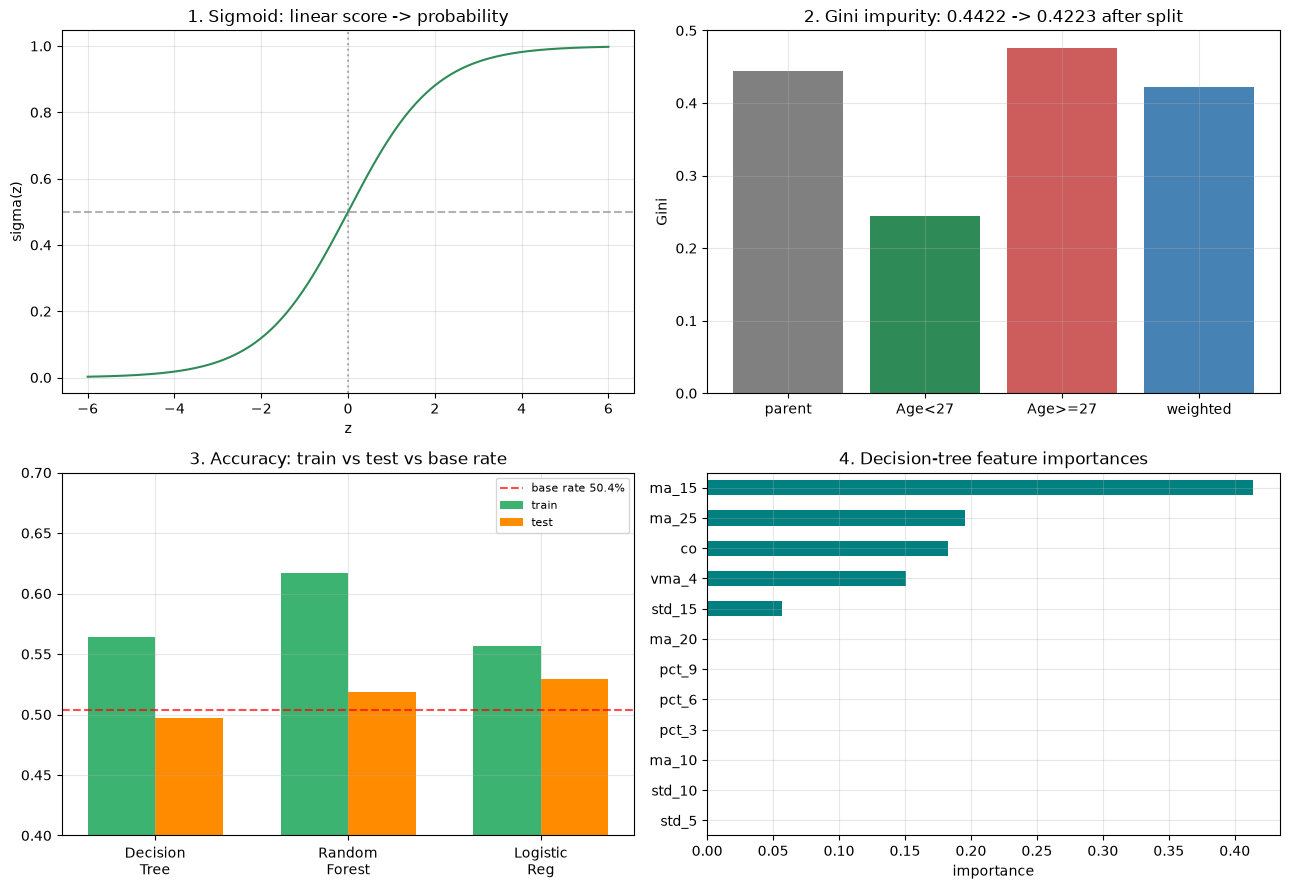

saved chart_1_ml.png


In [12]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# 1) the sigmoid
z = np.linspace(-6, 6, 200)
ax[0,0].plot(z, 1/(1+np.exp(-z)), color='seagreen')
ax[0,0].axhline(0.5, color='gray', ls='--', alpha=.6); ax[0,0].axvline(0, color='gray', ls=':', alpha=.6)
ax[0,0].set_title('1. Sigmoid: linear score -> probability'); ax[0,0].set_xlabel('z'); ax[0,0].set_ylabel('sigma(z)')

# 2) Gini reduction
ax[0,1].bar(['parent','Age<27','Age>=27','weighted'], [parent, g_left, g_right, w_gini],
            color=['gray','seagreen','indianred','steelblue'])
ax[0,1].set_title('2. Gini impurity: 0.4422 -> 0.4223 after split'); ax[0,1].set_ylabel('Gini')

# 3) model accuracy comparison
models = ['Decision\nTree', 'Random\nForest', 'Logistic\nReg']
tr = [dt.score(X_train,y_train), rf.score(X_train,y_train), lr.score(X_train_scaled,y_train)]
te = [dt.score(X_test,y_test),  rf.score(X_test,y_test),  lr.score(X_test_scaled,y_test)]
x = np.arange(3); w = 0.35
ax[1,0].bar(x-w/2, tr, w, label='train', color='mediumseagreen')
ax[1,0].bar(x+w/2, te, w, label='test',  color='darkorange')
ax[1,0].axhline(0.504, color='red', ls='--', alpha=.7, label='base rate 50.4%')
ax[1,0].set_xticks(x); ax[1,0].set_xticklabels(models); ax[1,0].set_ylim(0.4, 0.7)
ax[1,0].set_title('3. Accuracy: train vs test vs base rate'); ax[1,0].legend(fontsize=8)

# 4) DT feature importances
imp.sort_values().plot.barh(ax=ax[1,1], color='teal')
ax[1,1].set_title('4. Decision-tree feature importances'); ax[1,1].set_xlabel('importance')

plt.tight_layout()
plt.savefig('chart_1_ml.png', dpi=110, bbox_inches='tight', facecolor='white')
plt.show()
print('saved chart_1_ml.png')

---
### Recap — what MLT-01 established (on real TSLA data)
- **ML learns feature → target associations.** Supervised needs a labelled target; unsupervised finds structure alone.
- **Decision trees** split to reduce **Gini impurity** (0.4422 → 0.4223 on the slide example); they **overfit**, so we
  prune and prefer simpler trees (Occam's razor).
- **Random forests** average many random trees and **generalise better** (test 51.9% vs the tree's 49.7%).
- **Logistic regression** maps a linear score through the **sigmoid** to a probability; it needs **scaling** (fit on
  train only) and scored **53.0%** test here.
- Across all three, next-day direction sits near the **~50% base rate** — the honest baseline. The real edge is in
  **feature engineering** and **proper evaluation**, which is exactly where MLT-02 goes next.